not usable right now because there is a bug with the data organisation -> use sim_44_data_analysis_new instead

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim44.pkl", "rb") as f:
    all_results = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measures1.4.pkl", "rb") as f:
    mc_measures = pickle.load(f)

In [3]:
weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]
n_seeds = 3
seeds = [1, 2, 3]
n_policies = 4

sorted_weight_trials = sorted(weight_trials)

time_interval = [80000000,100000000]

In [4]:
'''
data structure all_results:
number of weight trials, each containing a dict for each policy (4), all contain corresponding to the policy:
Index(['0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min'],
      dtype='object')
'''

"\ndata structure all_results:\nnumber of weight trials, each containing a dict for each policy (4), all contain corresponding to the policy:\nIndex(['0/len/len',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',\n       '0/reward/reward_min', '0/len/len',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',\n       '0/reward/reward_min', '0/len/len',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',\n       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',\n       '0/reward/reward_min'],\n      dtype='object')\n"

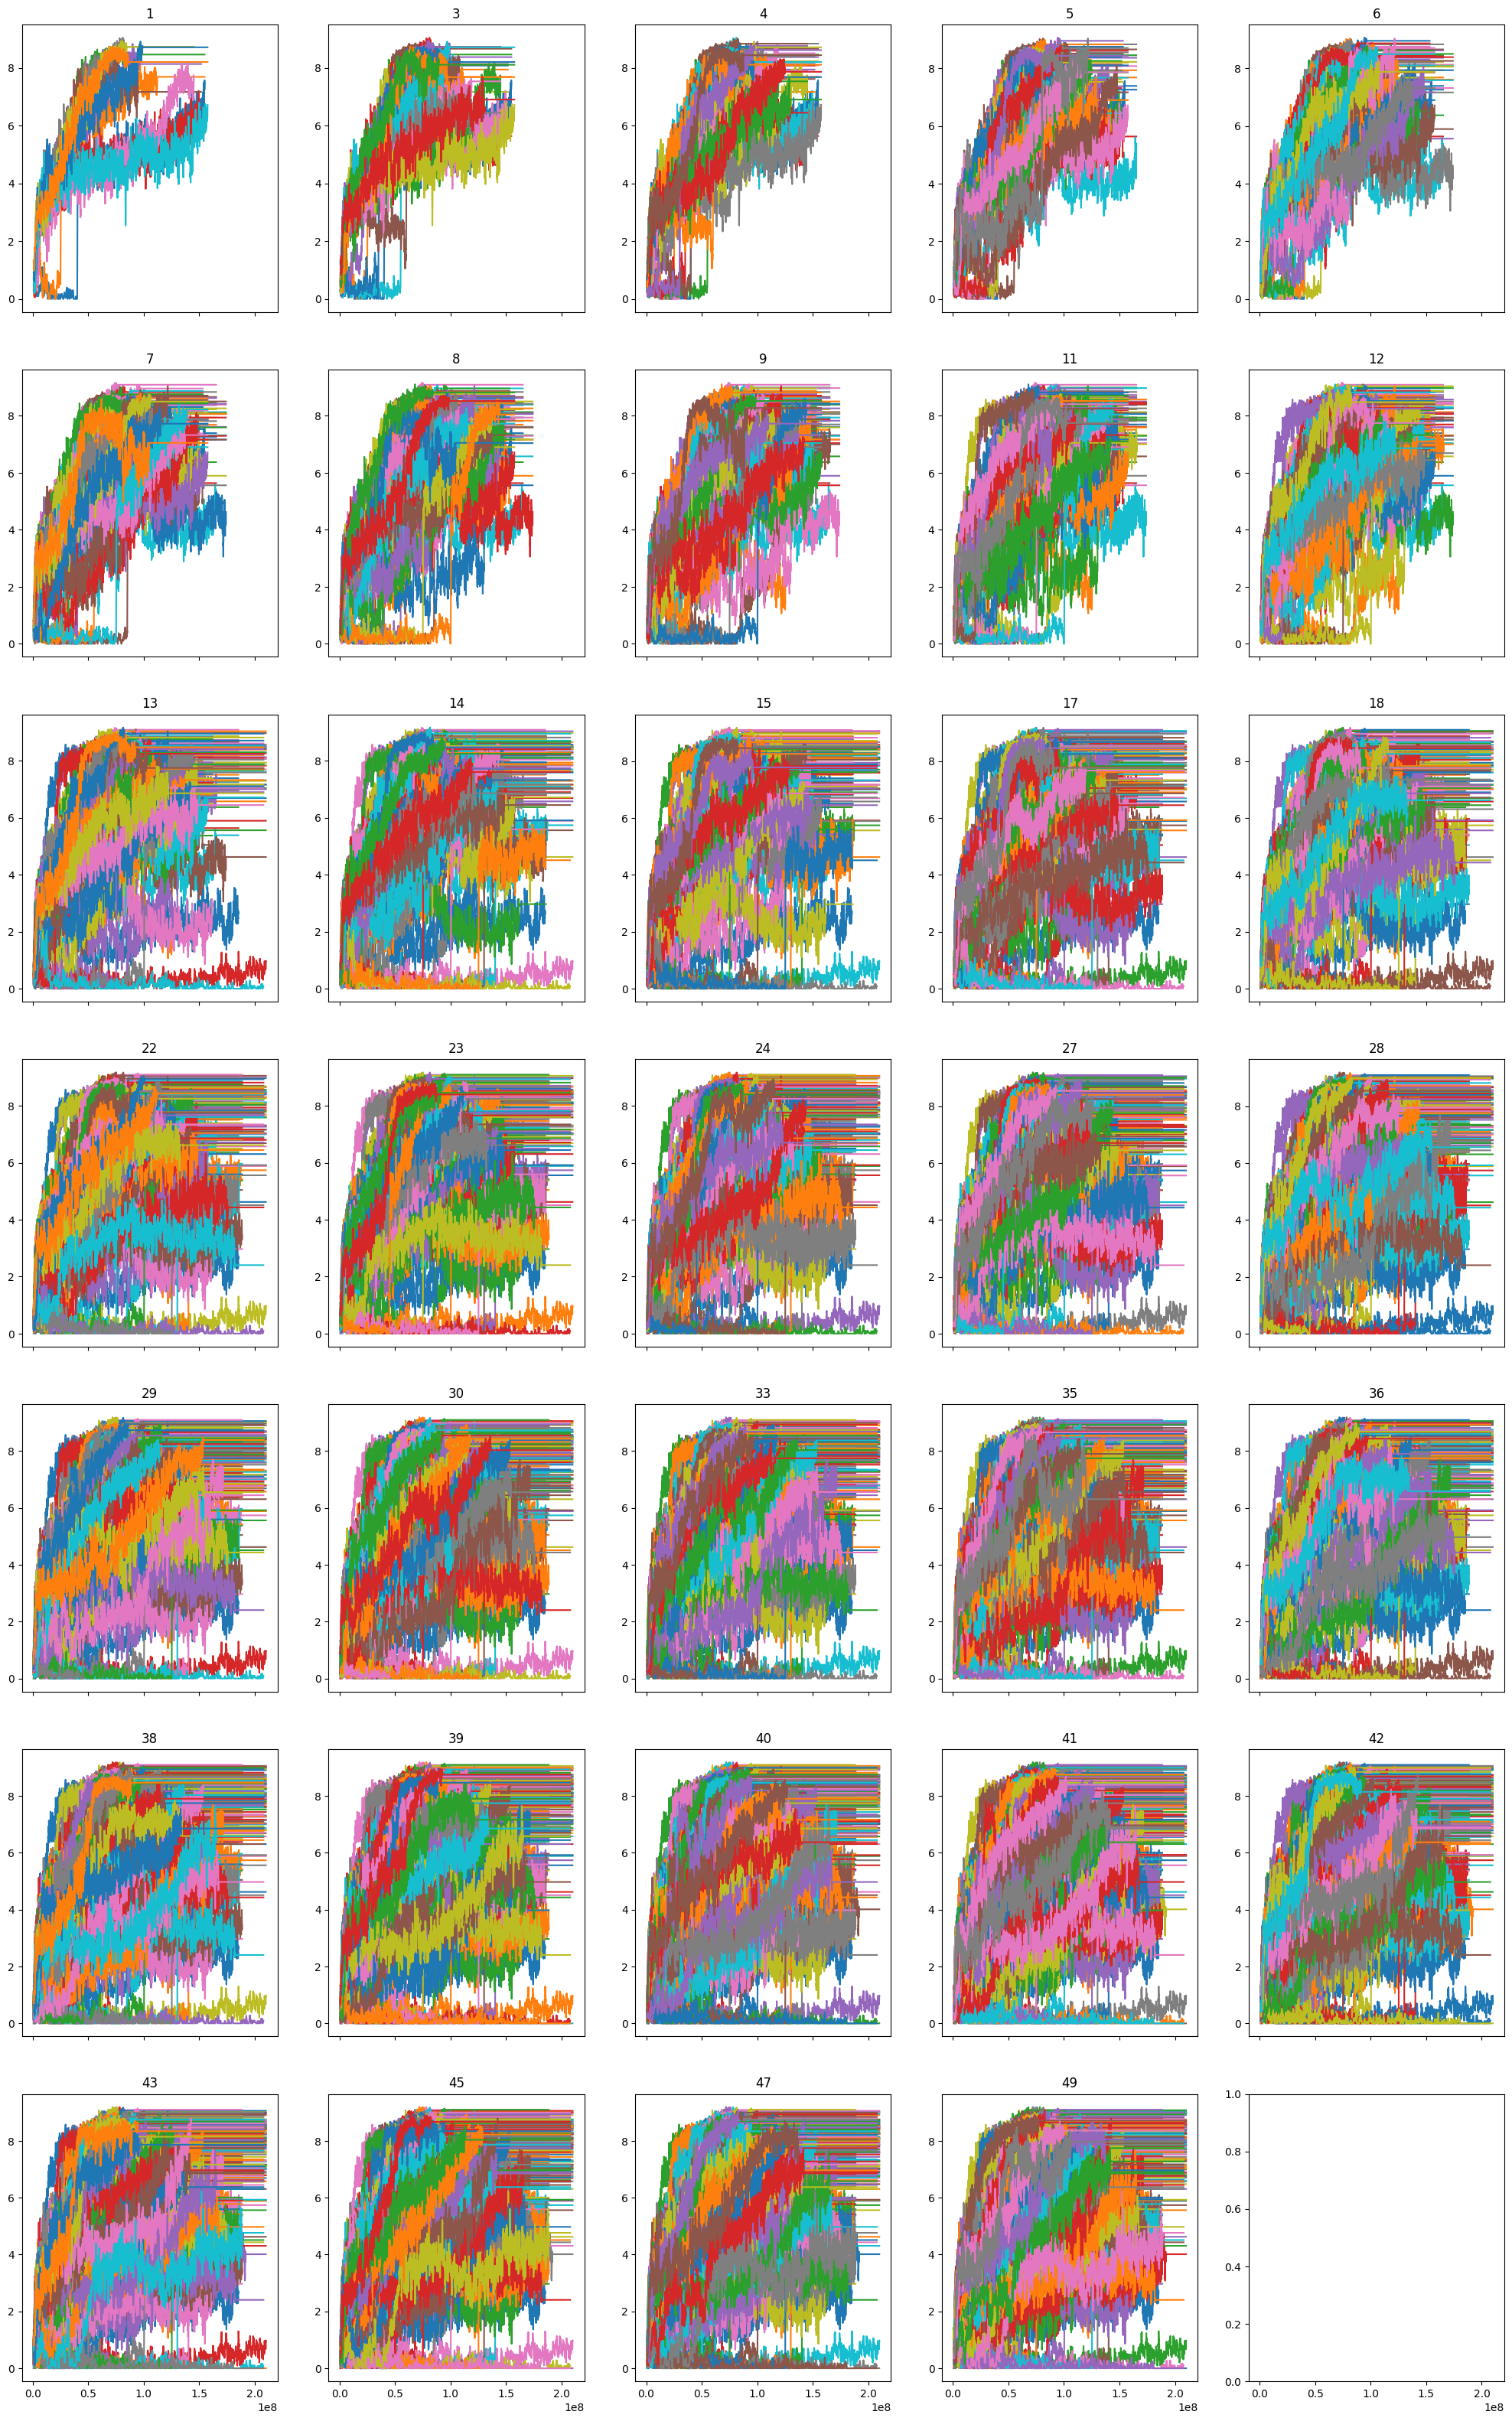

In [28]:
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
    
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = all_results[t][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

In [5]:
all_results_rearranged = dict()

for trial in weight_trials:
    df_seeds = {1:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for policy in range(n_policies):
        raw_scores = all_results[trial][policy].loc[:,f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
        lenweighted_scores = all_results[trial][policy].loc[:,f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
        reward_mins = all_results[trial][policy].loc[:,f'{policy}/reward/reward_min']
        lens = all_results[trial][policy].loc[:,f'{policy}/len/len']

        for seed in range(1, n_seeds+1):
            df_seeds[seed]['raw_score'] = pd.concat([df_seeds[seed]['raw_score'],raw_scores.iloc[:, seed-1]], axis=1).sort_index()
            df_seeds[seed]['lenweighted_score'] = pd.concat([df_seeds[seed]['lenweighted_score'],lenweighted_scores.iloc[:, seed-1]], axis=1)
            df_seeds[seed]['reward_min'] = pd.concat([df_seeds[seed]['reward_min'],reward_mins.iloc[:, seed-1]], axis=1)
            df_seeds[seed]['len'] = pd.concat([df_seeds[seed]['len'],lens.iloc[:, seed-1]], axis=1)
    all_results_rearranged[trial] = df_seeds

# data structure all_results_rearranged:
# dict of weight trials, dict of seeds, dict of metrics

new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3
new plot
1
2
3


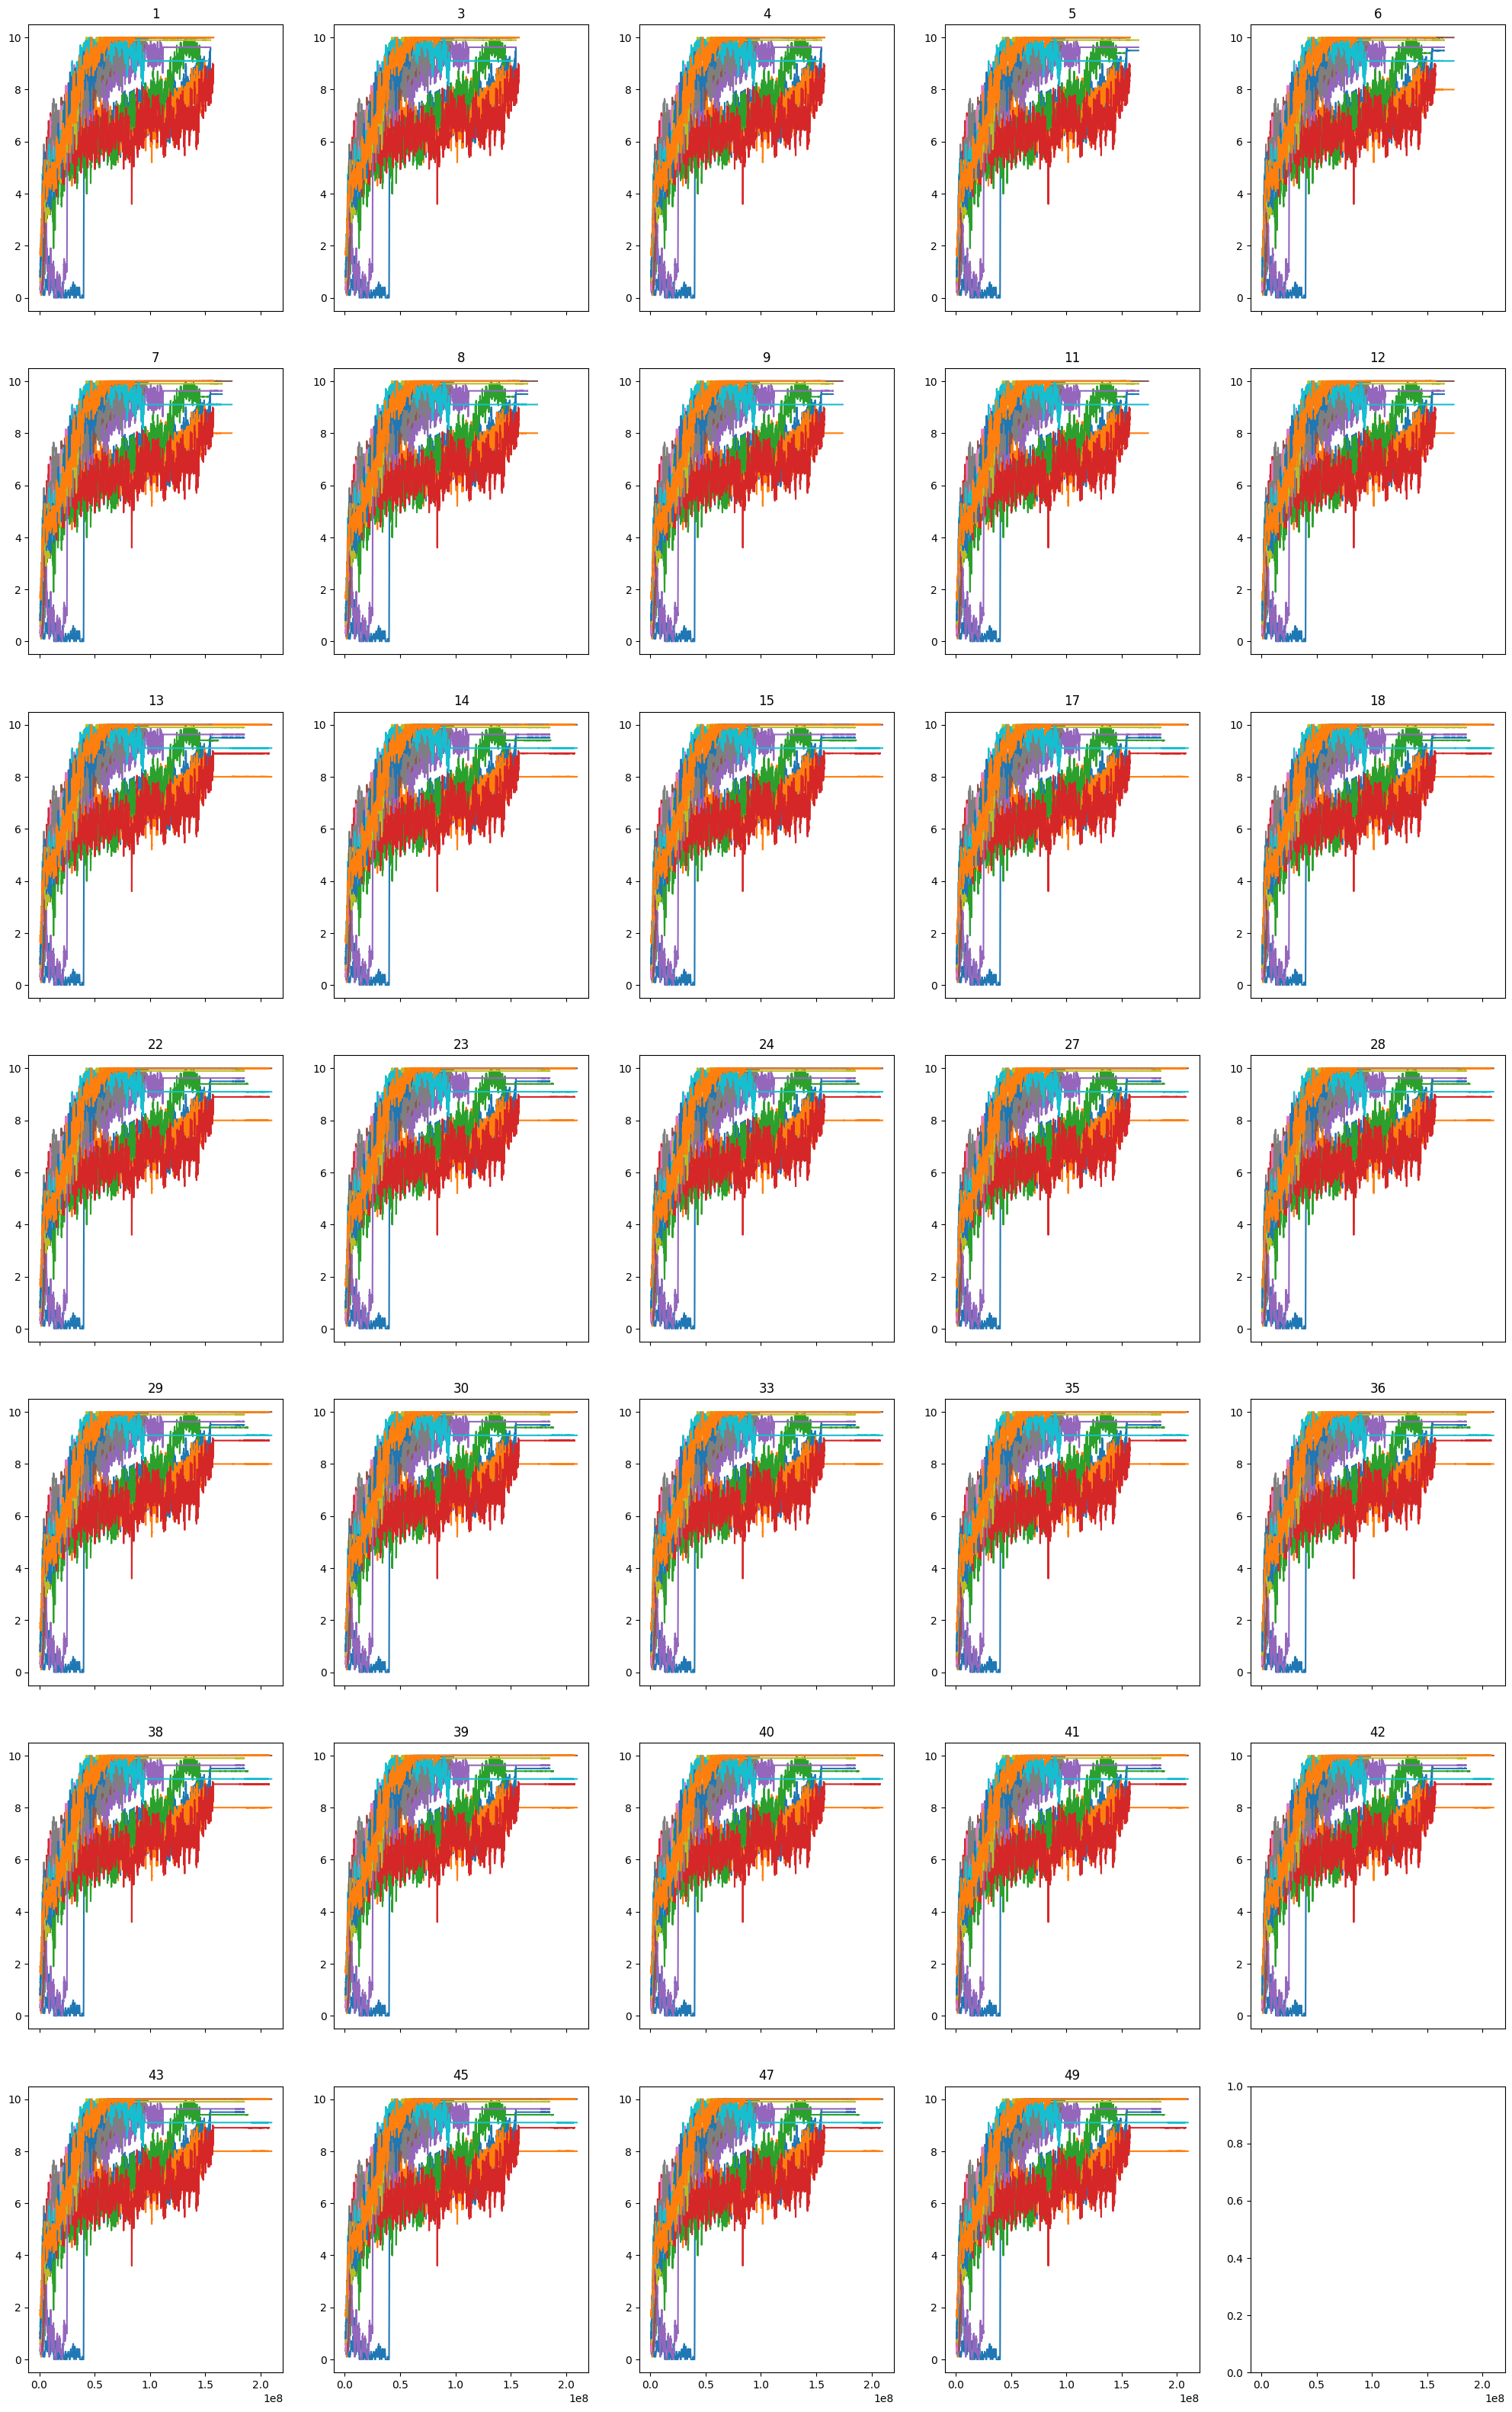

In [27]:
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    print('new plot')
    for seed in range(1, n_seeds+1):
        print(seed)
        raw_score = all_results_rearranged[t][seed]['raw_score']
        idx = all_results_rearranged[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

In [6]:
mean_results_by_seeds = dict()

for trial in weight_trials:
    df_seed = {1:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for seed in range(1, n_seeds+1):
        df_seed[seed]['raw_score'] = all_results_rearranged[trial][seed]['raw_score'].mean(axis=1)
        df_seed[seed]['lenweighted_score'] = all_results_rearranged[trial][seed]['lenweighted_score'].mean(axis=1)
        df_seed[seed]['reward_min'] = all_results_rearranged[trial][seed]['reward_min'].mean(axis=1)
        df_seed[seed]['len'] = all_results_rearranged[trial][seed]['len'].mean(axis=1)
    mean_results_by_seeds[trial] = df_seed



In [7]:
print(sorted_weight_trials)

[1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]


In [8]:
# take the means
mean_results = dict()

for trial in weight_trials:
    dfs_by_mean_policy = dict()
    for policy in range(n_policies):
        dfs_by_mean_policy[policy] = all_results[trial][policy].T.groupby(level=0).mean().T
    mean_results[trial] = dfs_by_mean_policy

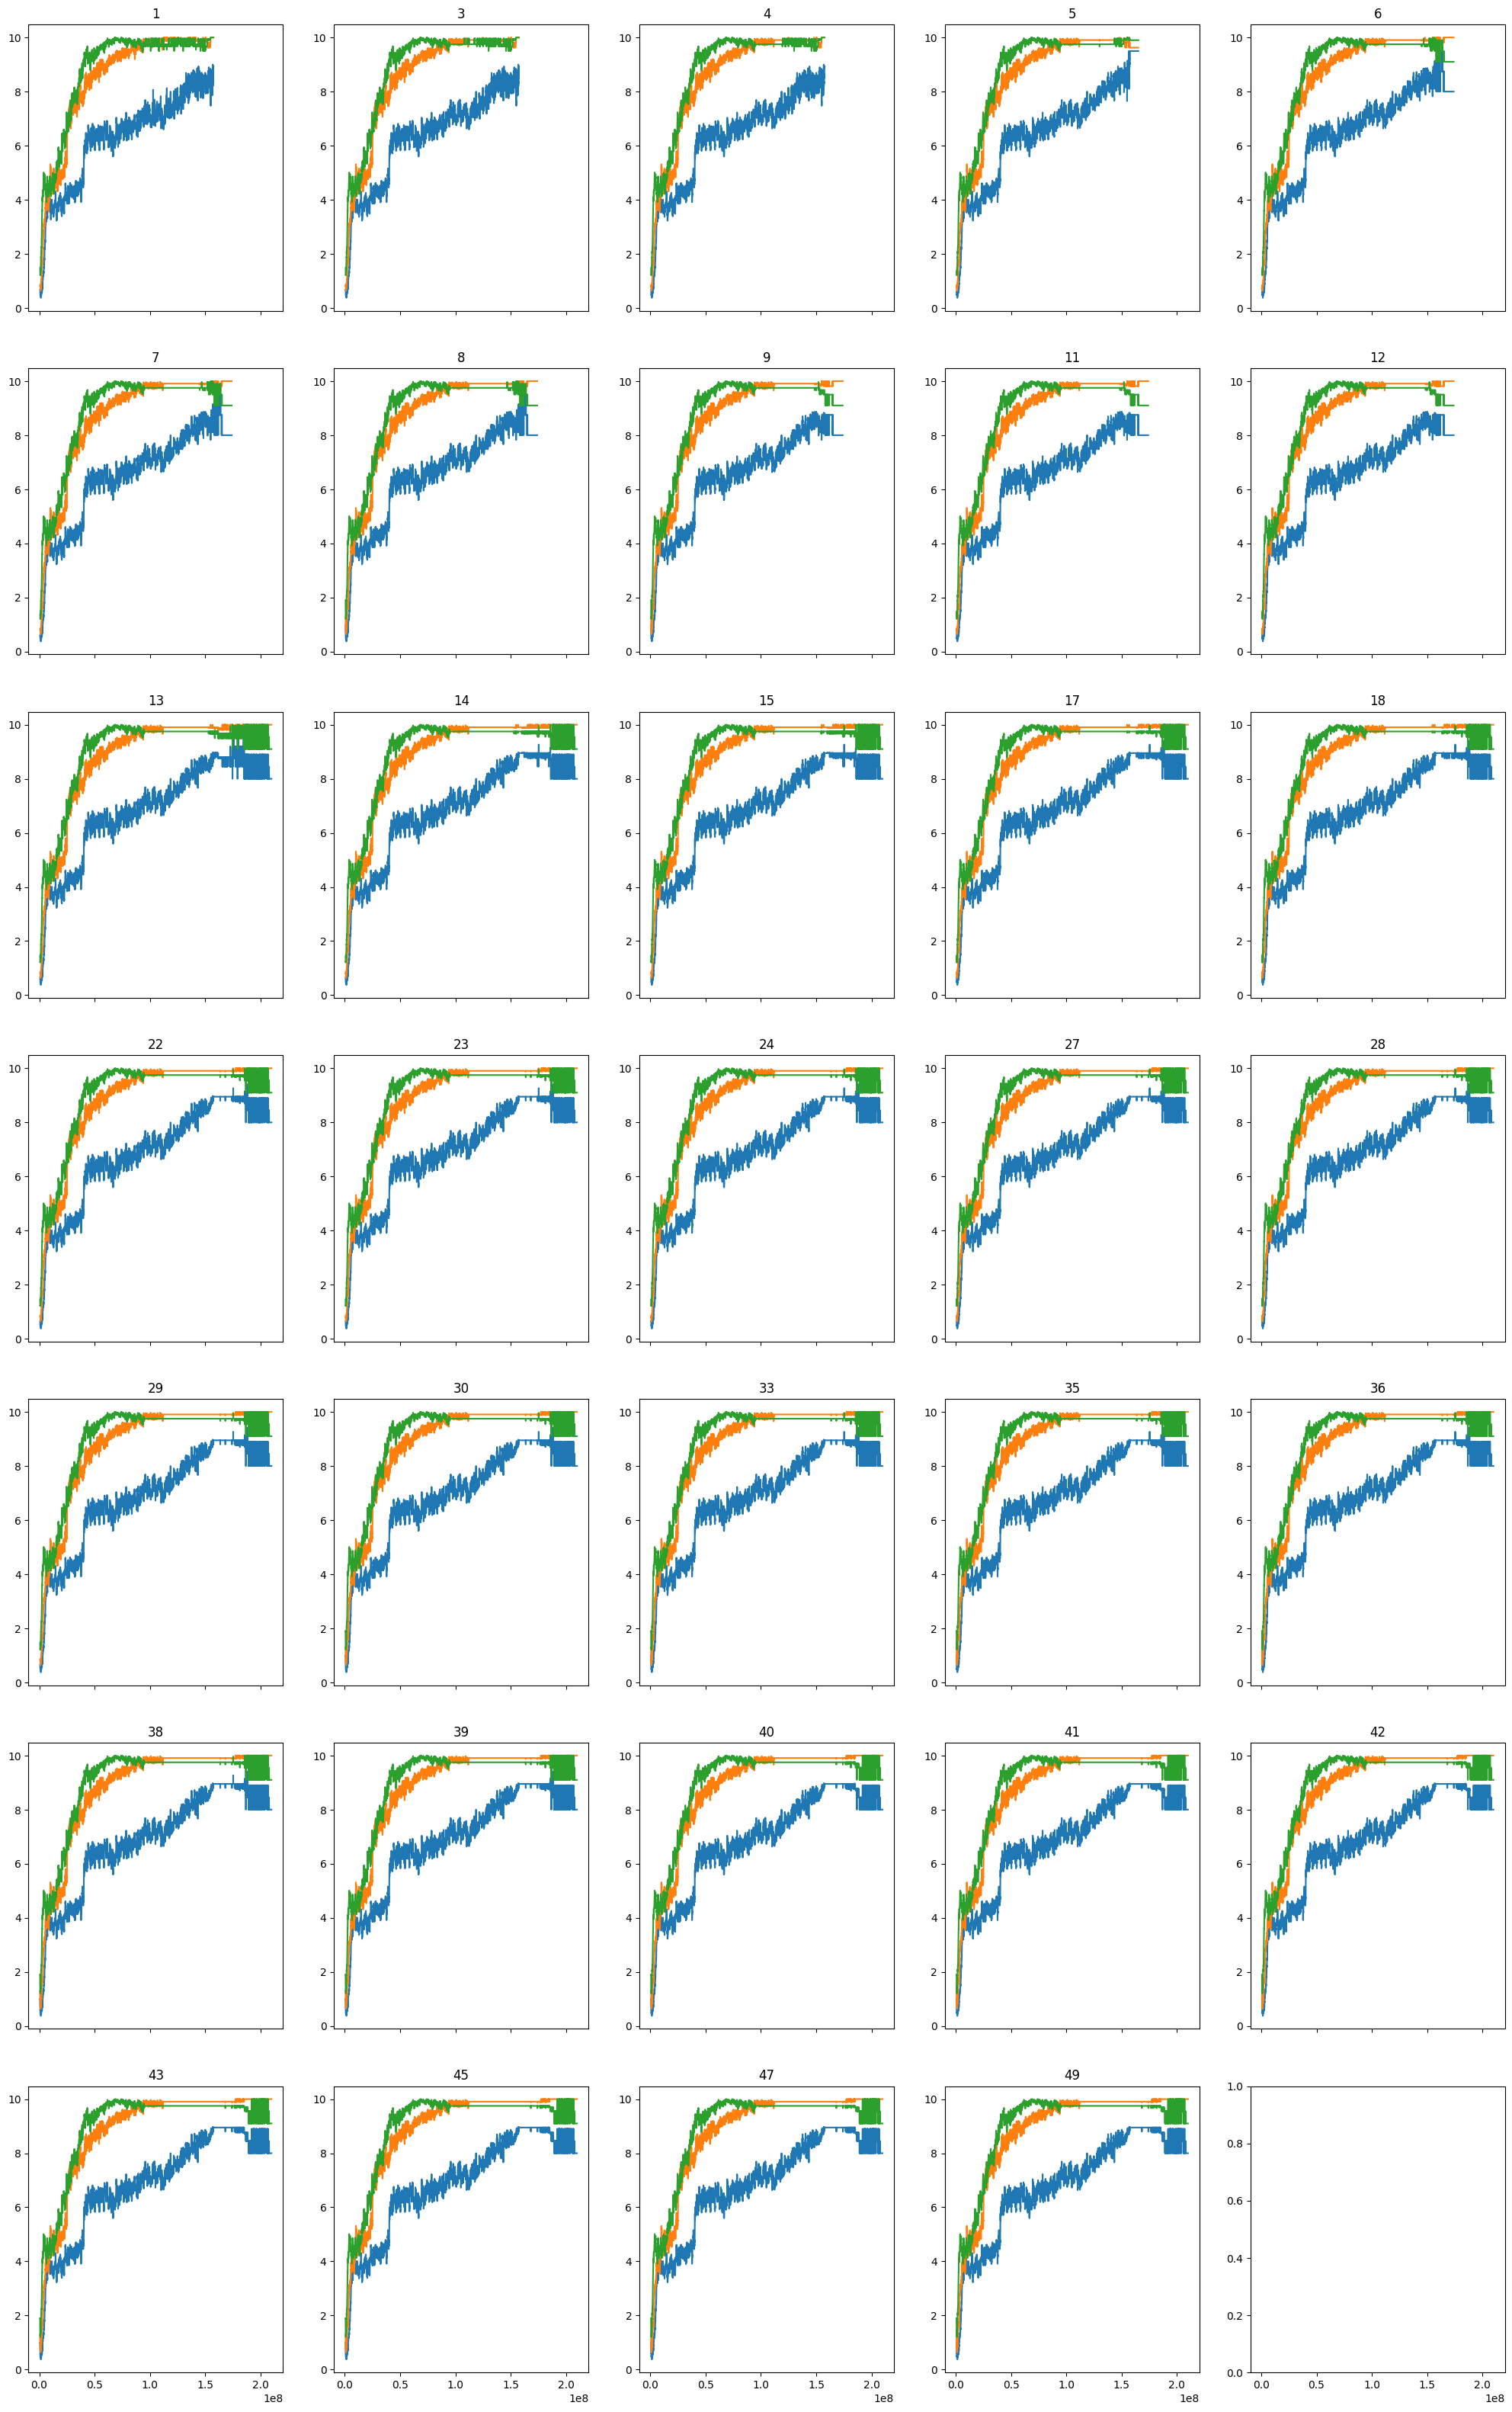

In [9]:
# plot the raw score curves for all weight trials & policies
'''
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = mean_results[t][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')
'''

fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for seed in range(1, n_seeds+1):
        raw_score = mean_results_by_seeds[t][seed]['raw_score']
        idx = mean_results_by_seeds[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

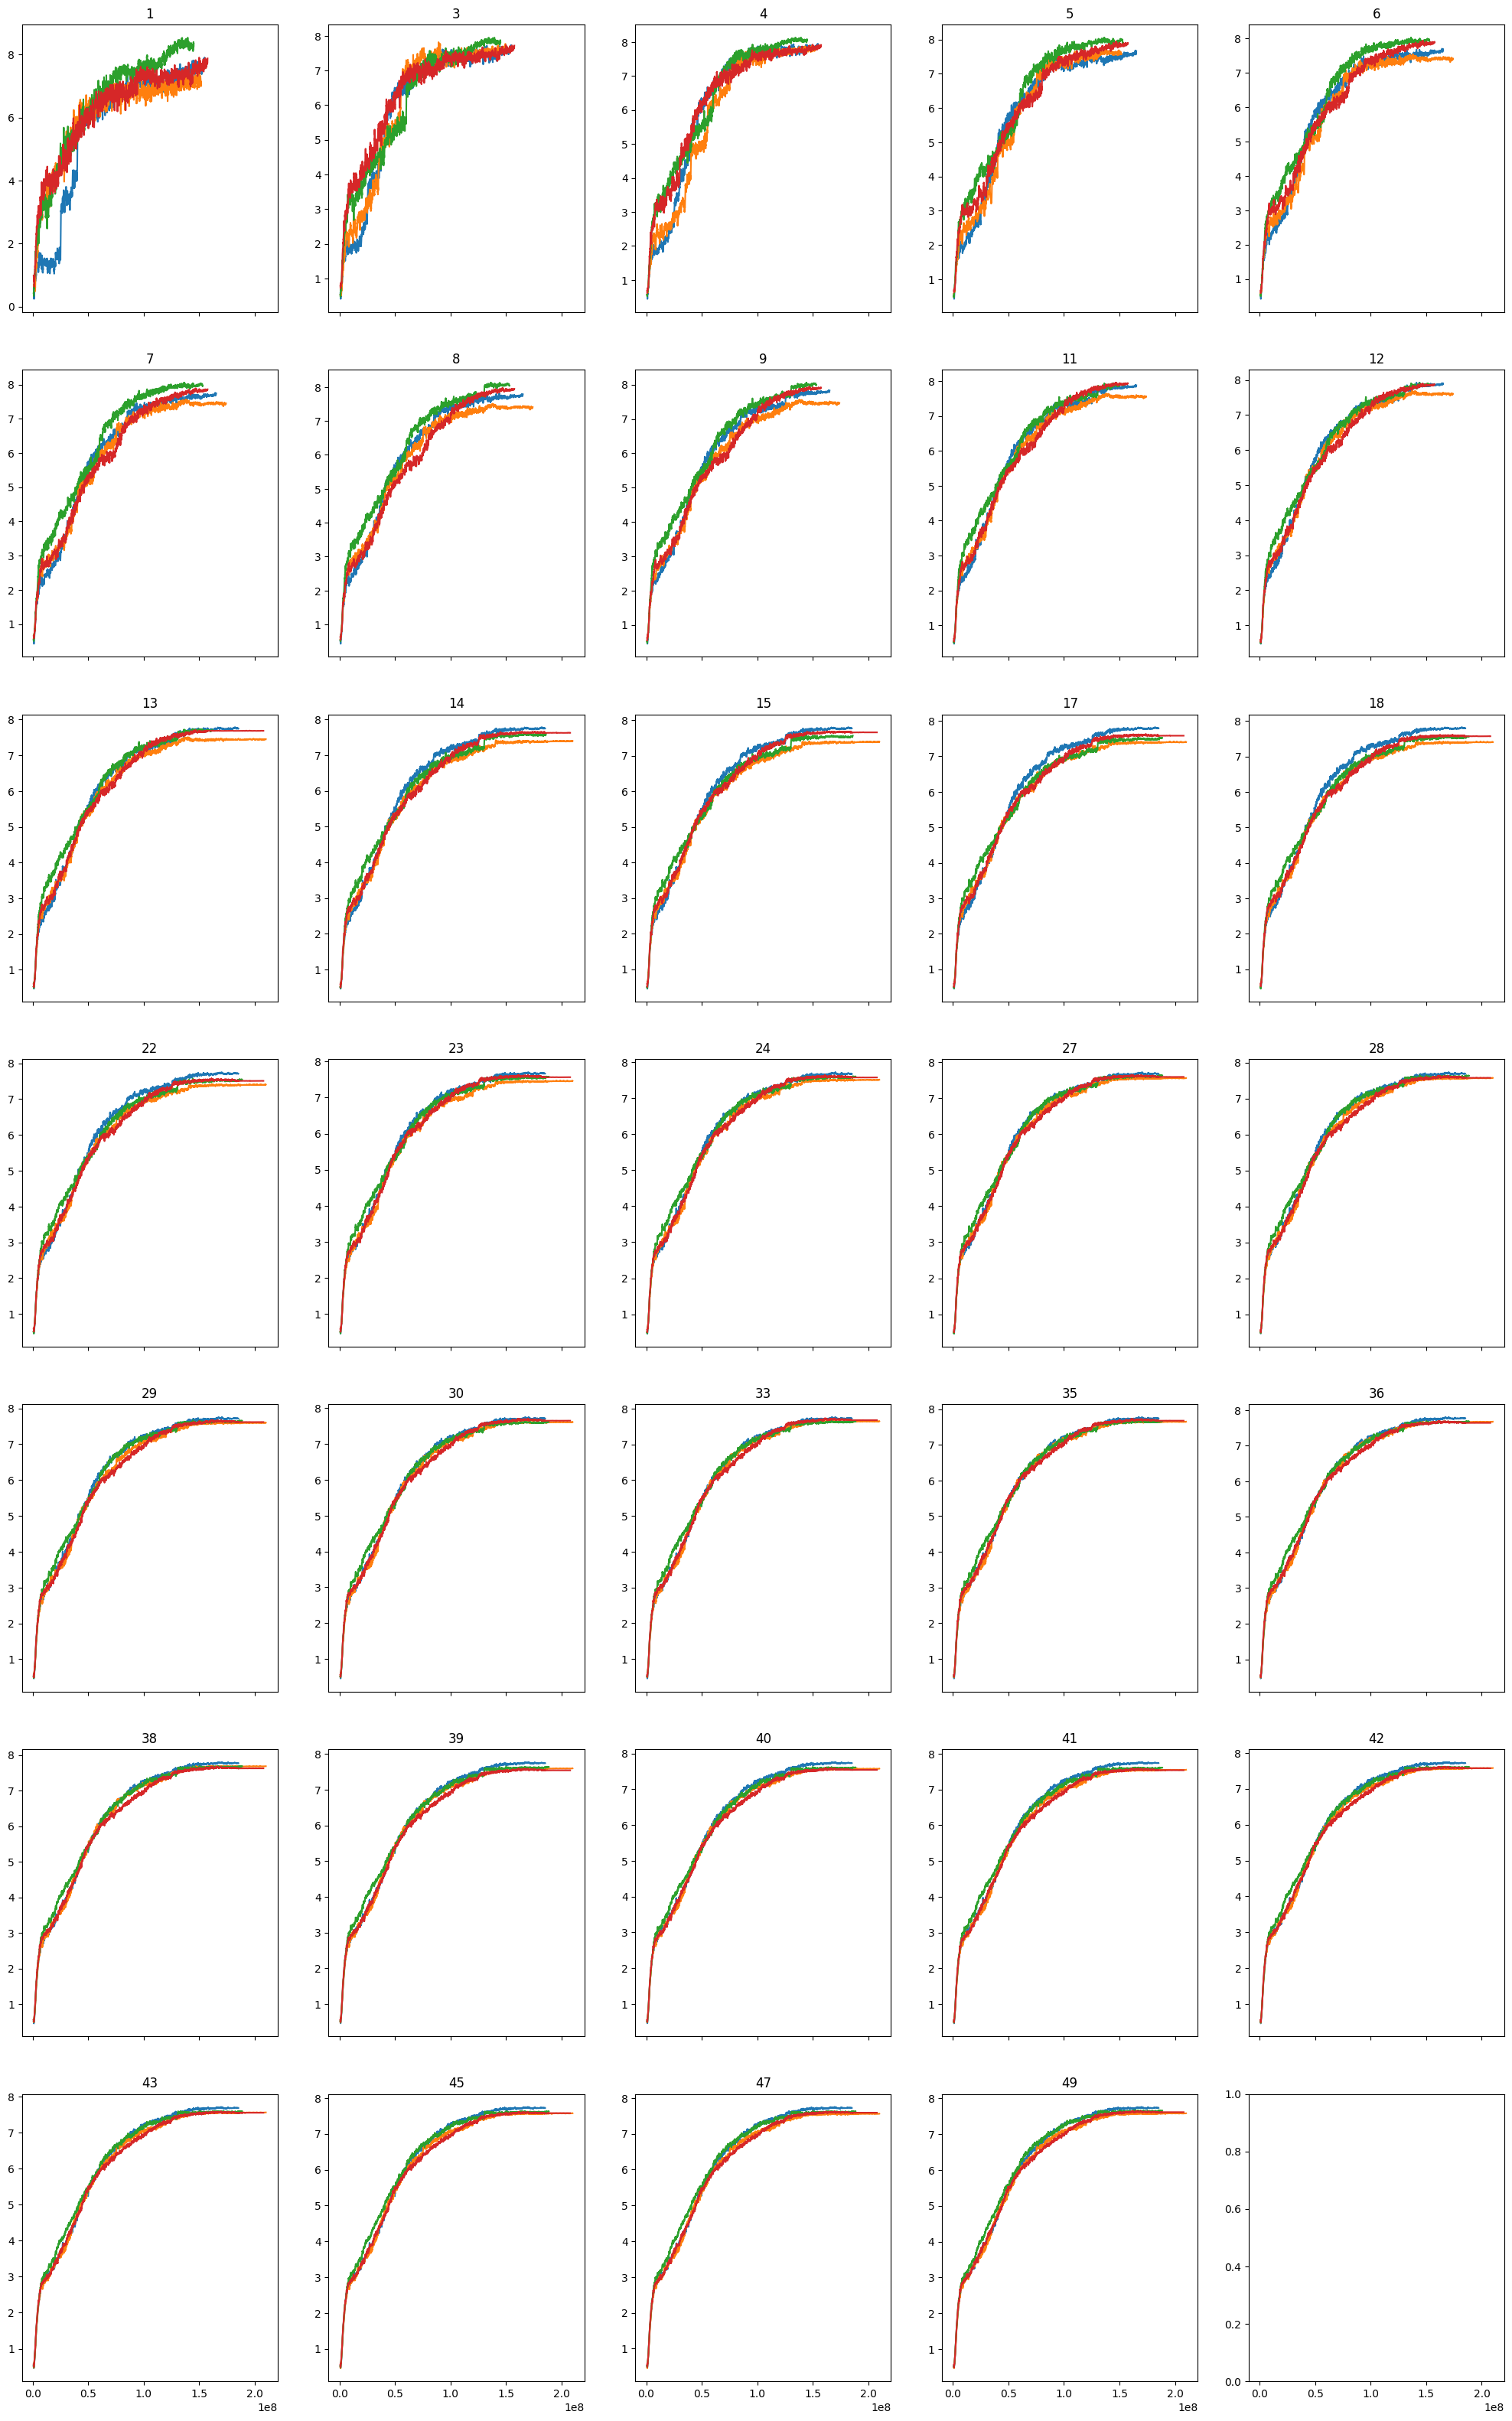

In [10]:
# plot the lenweighted score curves for all weight trials & policies
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = mean_results[t][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

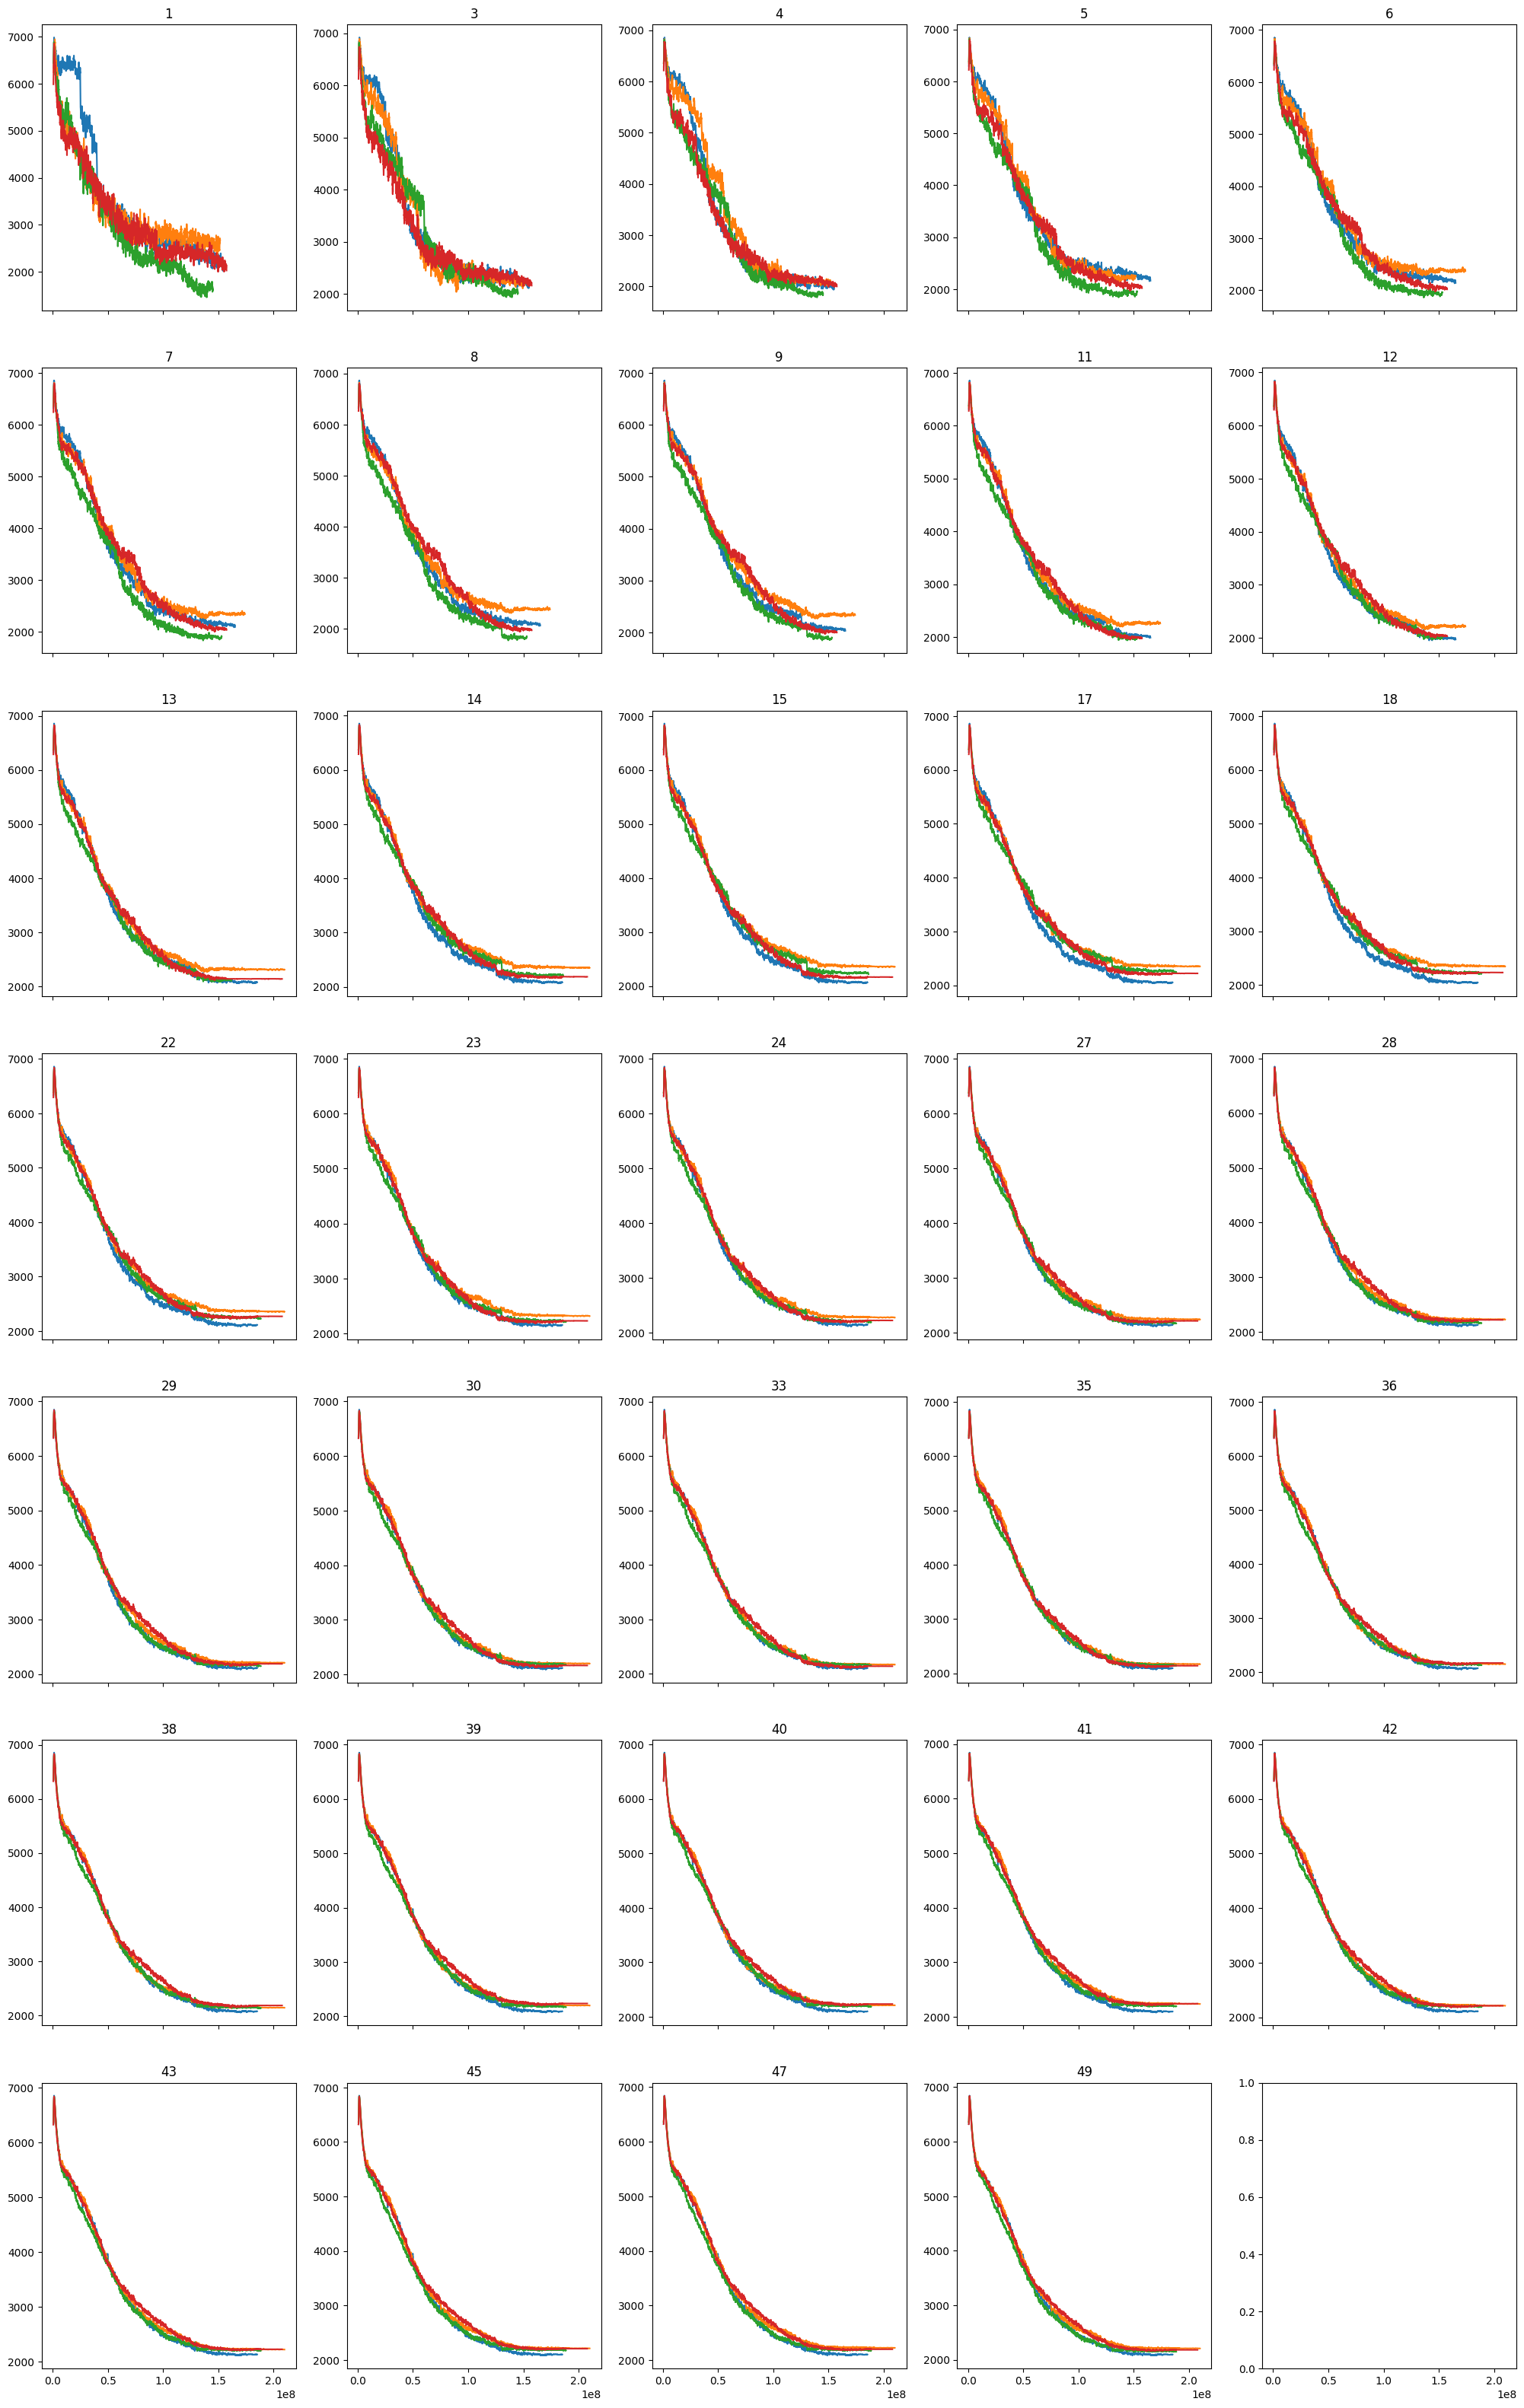

In [11]:
# plot the len score curves for all weight trials & policies
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = mean_results[t][policy][f'{policy}/len/len']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

In [29]:
# take the mean of a metric for the relevant time interval

mean_raw_score_time_interval = []
for seed in seeds:
    scores = []
    for trial in weight_trials:
        #raw_score = mean_results[trial][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
        raw_score = mean_results_by_seeds[trial][seed]['raw_score']
        raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
        scores.append(raw_score_time_interval.mean())
    mean_raw_score_time_interval.append(scores)

/tmp/ipykernel_2605330/3096214673.py:9: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]


In [30]:
print(mean_raw_score_time_interval)

[[6.8982091246043655, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582, 6.898100324837582], [9.678062426287688, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.682472126199638, 9.68247

In [16]:
print(len(mean_raw_score_time_interval[0]))

34


#### homemade MC measures

In [14]:
print(mc_measures.keys())

dict_keys(['tau_orth_vec', 'tau_orth_vec_not_norm', 'orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])


1
2
3


Text(0, 0.5, 'performance - mean raw score')

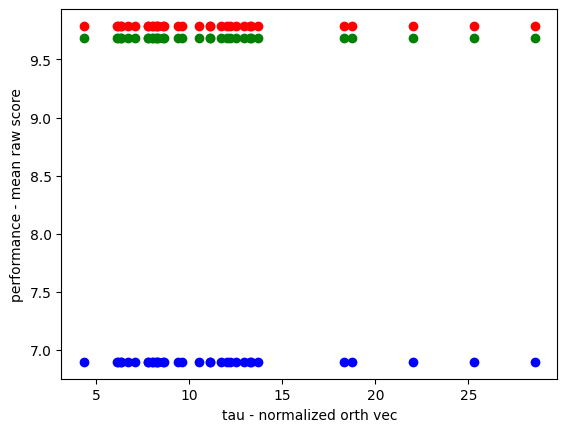

In [23]:
# scatter plot the performance measure vs the MC measure
colors = ['b', 'g', 'r']
plt.figure()
#for policy in range(n_policies):
#    plt.scatter(mc_measures['tau_orth_vec'], mean_raw_score_time_interval[policy], c='b')
for seed in seeds:
    print(seed)
    plt.scatter(mc_measures['tau_orth_vec'], mean_raw_score_time_interval[seed-1], c=colors[seed-1])
plt.xlabel('tau - normalized orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

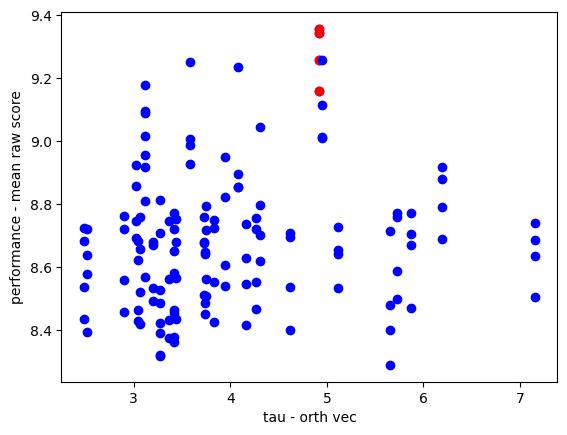

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['tau_orth_vec_not_norm'], mean_raw_score_time_interval[policy], c='b')
    plt.scatter(mc_measures['tau_orth_vec_not_norm'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('tau - orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

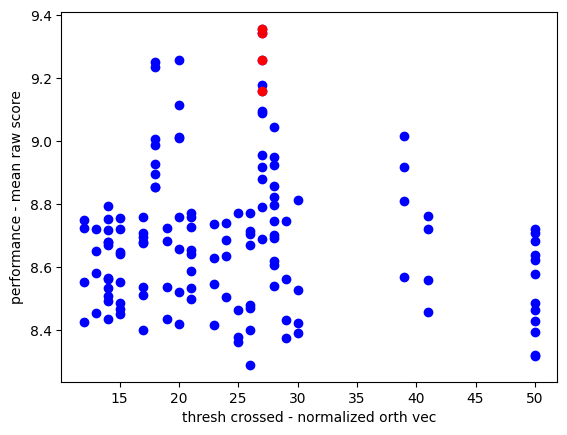

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval[policy], c='b')
    plt.scatter(mc_measures['orth_vec_thresh_crossed'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('thresh crossed - normalized orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

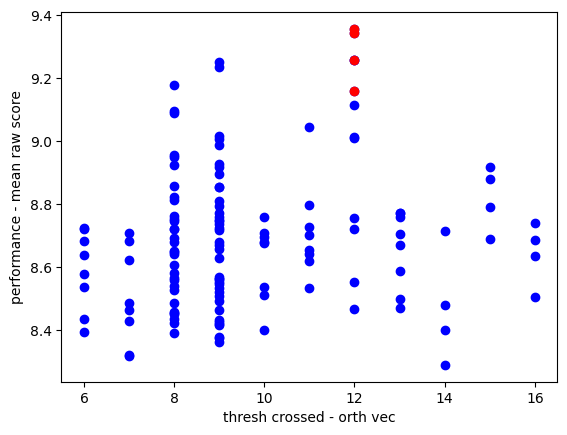

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['orth_vec_thresh_crossed_not_norm'], mean_raw_score_time_interval[policy], c='b')
for policy in range(n_policies):
    plt.scatter(mc_measures['orth_vec_thresh_crossed_not_norm'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('thresh crossed - orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

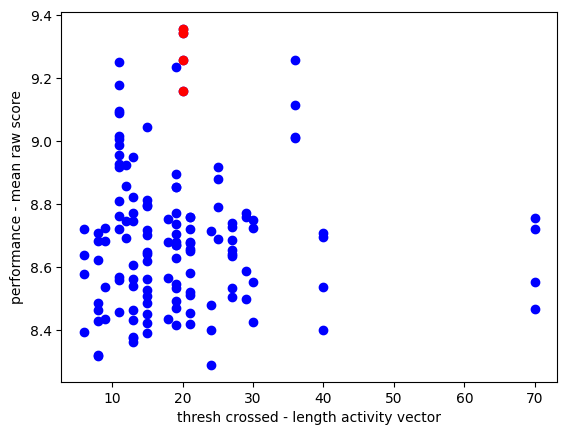

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['norm_thresh_crossed'], mean_raw_score_time_interval[policy], c='b')
for policy in range(n_policies):
    plt.scatter(mc_measures['norm_thresh_crossed'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('thresh crossed - length activity vector')
plt.ylabel('performance - mean raw score')

#### Giovanni et.al., SVD, participation ratio

Text(0, 0.5, 'performance - mean raw score')

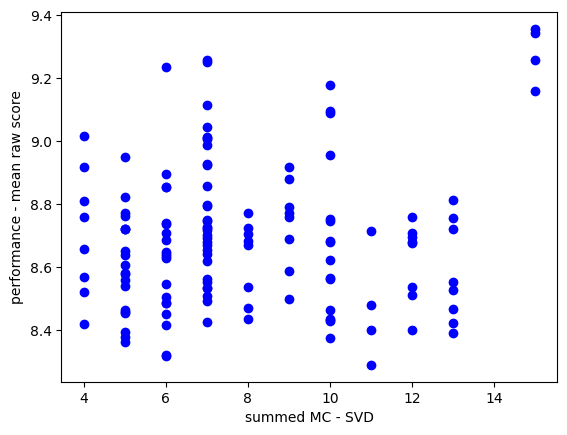

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['summed_MC_svd'], mean_raw_score_time_interval[policy], c='b')
plt.xlabel('summed MC - SVD')
plt.ylabel('performance - mean raw score')

In [ ]:
np.argmax(mc_measures['summed_MC_svd'])

2

Text(0, 0.5, 'performance - mean raw score')

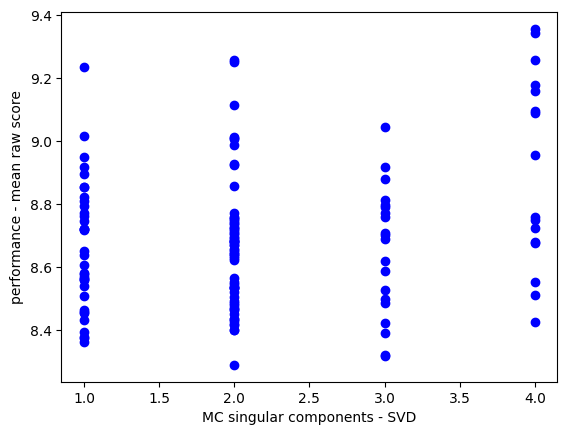

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['MC_singular_components_svd'], mean_raw_score_time_interval[policy], c='b')
plt.xlabel('MC singular components - SVD')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

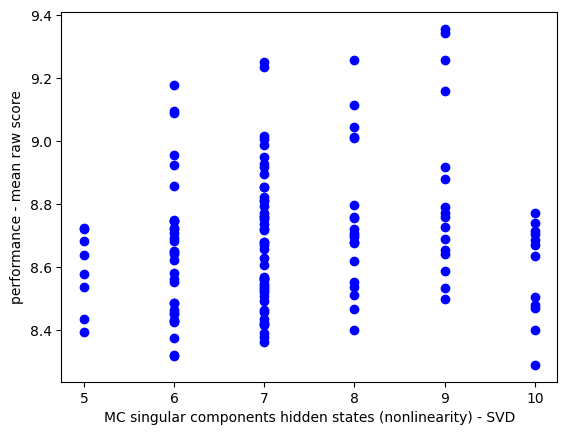

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['MC_singular_components_hs_svd'], mean_raw_score_time_interval[policy], c='b')
plt.xlabel('MC singular components hidden states (nonlinearity) - SVD')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

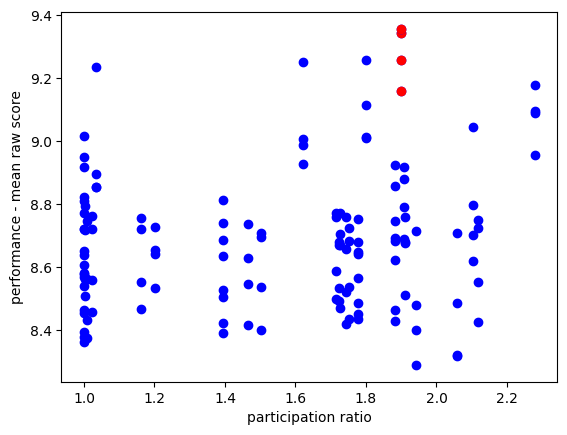

In [ ]:
plt.figure()
for policy in range(n_policies):
    plt.scatter(mc_measures['participation_ratio_svd'], mean_raw_score_time_interval[policy], c='b')
    plt.scatter(mc_measures['participation_ratio_svd'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('participation ratio')
plt.ylabel('performance - mean raw score')